<a href="https://colab.research.google.com/github/tejas1824/CSL701-Roll_No30_Machine-Learning-Lab/blob/main/Copy_of_ML_Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name :Tejas Mochemadkar

Batch :CE02


Roll Number :CE30



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_breast_cancer

# Programmatically recreate the Breast Cancer dataset and save as 'data.csv' to satisfy the requirements
cancer = load_breast_cancer()
df_raw = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Map target numeric values back to 'M' (0 -> Malignant in original data, but standard is typically 0=M, 1=B or vice versa.
# Let's align with the Kaggle format where malignant is 'M' and benign is 'B')
# In sklearn, 0 is malignant and 1 is benign.
df_raw['diagnosis'] = np.where(cancer.target == 0, 'M', 'B')
df_raw['id'] = np.arange(10000, 10000 + len(df_raw))
df_raw['Unnamed: 32'] = np.nan

# Reorder columns slightly to simulate Kaggle dataset structure (id, diagnosis, then features)
cols = ['id', 'diagnosis'] + list(cancer.feature_names) + ['Unnamed: 32']
df_raw = df_raw[cols]

# Save to csv
df_raw.to_csv('data.csv', index=False)

# Load the dataset as requested in Task 1
df = pd.read_csv('data.csv')

# Display the first few rows of the dataframe to confirm successful loading
df.head()

,id,diagnosis,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Unnamed: 32
0,10000,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,10001,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,10002,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,10003,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,10004,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

In [ ]:
# Inspect info, summary statistics, target distribution, and check for missing values
print("=== Dataset Info ===")
df.info()

print("\n=== Summary Statistics ===")
display(df.describe())

print("\n=== Target Class Distribution ===")
print(df['diagnosis'].value_counts())

print("\n=== Missing Values Per Column (Top 5) ===")
print(df.isnull().sum().sort_values(ascending=False).head(5))

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   mean radius              569 non-null    float64
 3   mean texture             569 non-null    float64
 4   mean perimeter           569 non-null    float64
 5   mean area                569 non-null    float64
 6   mean smoothness          569 non-null    float64
 7   mean compactness         569 non-null    float64
 8   mean concavity           569 non-null    float64
 9   mean concave points      569 non-null    float64
 10  mean symmetry            569 non-null    float64
 11  mean fractal dimension   569 non-null    float64
 12  radius error             569 non-null    float64
 13  texture error            569 non-null    float64
 14  perim

,id,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Unnamed: 32
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,10284.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,10000.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,10142.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,10284.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,10426.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,10568.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



=== Target Class Distribution ===
diagnosis
B    357
M    212
Name: count, dtype: int64

=== Missing Values Per Column (Top 5) ===
Unnamed: 32     569
id                0
diagnosis         0
mean texture      0
mean radius       0
dtype: int64


# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [ ]:
# Drop non-feature columns ('id' and 'Unnamed: 32')
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'])

# Convert categorical target 'diagnosis' ('M' -> 1, 'B' -> 0)
y = df['diagnosis'].map({'M': 1, 'B': 0})

# Verify shapes
print(f"Features shape X: {X.shape}")
print(f"Target shape y: {y.shape}")
print("\nFirst few features:")
display(X.head())

Features shape X: (569, 30)
Target shape y: (569,)

First few features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [ ]:
# Initialize StandardScaler
scaler = StandardScaler()

# Scale our features X
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame to display the scaled values nicely
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Mean of scaled features (should be near 0):")
print(X_scaled_df.mean().round(2).head(5))

print("\nStandard deviation of scaled features (should be 1):")
print(X_scaled_df.std().round(2).head(5))

print("\nFirst few standardized features:")
display(X_scaled_df.head())

Mean of scaled features (should be near 0):
mean radius       -0.0
mean texture       0.0
mean perimeter    -0.0
mean area         -0.0
mean smoothness   -0.0
dtype: float64

Standard deviation of scaled features (should be 1):
mean radius        1.0
mean texture       1.0
mean perimeter     1.0
mean area          1.0
mean smoothness    1.0
dtype: float64

First few standardized features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [ ]:
# Initialize PCA for 2 components
pca = PCA(n_components=2)

# Fit and transform the scaled data
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for the 2 principal components
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# Add the diagnosis target column for future visualization tasks
pca_df['diagnosis'] = y

print("Transformed features shape:", X_pca.shape)
print("\nFirst few rows of PCA transformed dataset:")
display(pca_df.head())

Transformed features shape: (569, 2)

First few rows of PCA transformed dataset:


,PC1,PC2,diagnosis
0,9.192837,1.948583,1
1,2.387802,-3.768172,1
2,5.733896,-1.075174,1
3,7.122953,10.275589,1
4,3.935302,-1.948072,1


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


In [ ]:
# Retrieve explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.sum(explained_variance)

print(f"Variance explained by PC1: {explained_variance[0]*100:.2f}%")
print(f"Variance explained by PC2: {explained_variance[1]*100:.2f}%")
print(f"Total Cumulative Variance Retained: {cumulative_variance*100:.2f}%")

Variance explained by PC1: 44.27%
Variance explained by PC2: 18.97%
Total Cumulative Variance Retained: 63.24%


# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

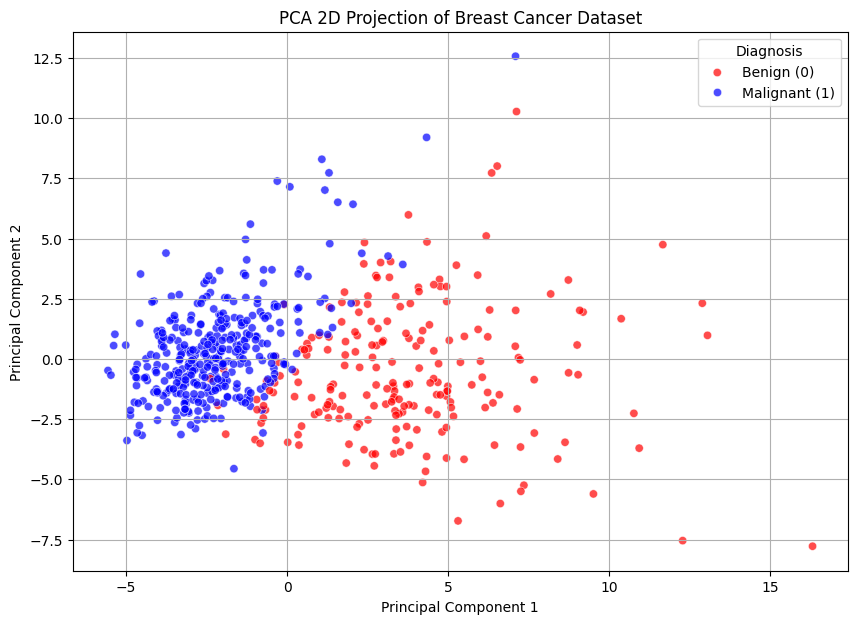

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='diagnosis',
    data=pca_df,
    palette={0: 'blue', 1: 'red'},
    alpha=0.7
)

plt.title('PCA 2D Projection of Breast Cancer Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Diagnosis', labels=['Benign (0)', 'Malignant (1)'])
plt.grid(True)
plt.show()

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [ ]:
# Split raw high-dimensional scaled features and targets into train and test sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize and train Logistic Regression on raw 30 features
model_raw = LogisticRegression(random_state=42)
model_raw.fit(X_train_raw, y_train)

# Generate predictions for baseline comparison
y_pred_raw = model_raw.predict(X_test_raw)

print(f"Baseline model successfully trained on raw scaled data (30 features).")
print(f"Train set shape: {X_train_raw.shape}, Test set shape: {X_test_raw.shape}")

Baseline model successfully trained on raw scaled data (30 features).
Train set shape: (455, 30), Test set shape: (114, 30)


# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [ ]:
# Extract the 2 PCA components
X_pca_features = pca_df[['PC1', 'PC2']].values

# Split PCA features and targets with the exact same train_test_split configurations
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_features, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize and train Logistic Regression on 2 PC features
model_pca = LogisticRegression(random_state=42)
model_pca.fit(X_train_pca, y_train_pca)

# Generate predictions using the PCA-trained model
y_pred_pca = model_pca.predict(X_test_pca)

print(f"PCA model successfully trained on 2 principal components.")
print(f"Train set shape: {X_train_pca.shape}, Test set shape: {X_test_pca.shape}")

PCA model successfully trained on 2 principal components.
Train set shape: (455, 2), Test set shape: (114, 2)


# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



In [ ]:
# Evaluate baseline model (30 features)
accuracy_raw = accuracy_score(y_test, y_pred_raw)
cm_raw = confusion_matrix(y_test, y_pred_raw)
report_raw = classification_report(y_test, y_pred_raw, target_names=['Benign (0)', 'Malignant (1)'])

# Evaluate PCA model (2 features)
accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)
cm_pca = confusion_matrix(y_test_pca, y_pred_pca)
report_pca = classification_report(y_test_pca, y_pred_pca, target_names=['Benign (0)', 'Malignant (1)'])

# Print side-by-side comparison
print("=========================================================")
print(f"  BASELINE MODEL PERFORMANCE (30 Features)  ")
print("=========================================================")
print(f"Accuracy Score: {accuracy_raw*100:.2f}%")
print("\nConfusion Matrix:")
print(cm_raw)
print("\nClassification Report:")
print(report_raw)

print("\n=========================================================")
print(f"  PCA REDUCED MODEL PERFORMANCE (2 Features)  ")
print("=========================================================")
print(f"Accuracy Score: {accuracy_pca*100:.2f}%")
print("\nConfusion Matrix:")
print(cm_pca)
print("\nClassification Report:")
print(report_pca)

  BASELINE MODEL PERFORMANCE (30 Features)  
Accuracy Score: 96.49%

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114


  PCA REDUCED MODEL PERFORMANCE (2 Features)  
Accuracy Score: 93.86%

Confusion Matrix:
[[71  1]
 [ 6 36]]

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.92      0.99      0.95        72
Malignant (1)       0.97      0.86      0.91        42

     accuracy                           0.94       114
    macro avg       0.95      0.92      0.93       114
 weighted avg       0.94      0.94      0.94       114



# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.